In [1]:
import torch

# Dynamically select the best available hardware
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # For Apple Silicon
    print("Using Apple M-series GPU")
else:
    device = torch.device("cpu")
    print("GPU not found, using CPU")

Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import torch

# For NVIDIA GPUs
print(f"CUDA available: {torch.cuda.is_available()}")

# For Apple Silicon (M1/M2/M3)
print(f"MPS available: {torch.backends.mps.is_available()}")

CUDA available: True
MPS available: False


In [3]:
import torch

# 1. Check if the version string has '+cu' in it
print(f"Torch Version: {torch.__version__}") 

# 2. Check if the GPU is visible
print(f"Is CUDA available? {torch.cuda.is_available()}")

# 3. Check which GPU is being seen
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

Torch Version: 2.9.1+cu126
Is CUDA available? True
Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
!nvidia-smi

Wed Jan  7 10:32:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.59                 Driver Version: 591.59         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   52C    P3              9W /   71W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch
import torch.nn as nn

class HSISuperRes3D(nn.Module):
    def __init__(self, in_channels=1, num_bands=103):
        super(HSISuperRes3D, self).__init__()
        
        # 3D Convolution: (Batch, Channels, Bands, Height, Width)
        # We use a small 3x3x3 kernel to capture local spectral-spatial features
        self.feature_extractor = nn.Sequential(
            nn.Conv3d(in_channels, 64, kernel_size=(3, 3, 3), padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(64, 64, kernel_size=(3, 3, 3), padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Upsampling layer: Using PixelShuffle (scaled for 3D or simple interpolation)
        # Here we use Upsample for simplicity in a 3D context
        self.upsampler = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        
        self.reconstruction = nn.Conv3d(64, in_channels, kernel_size=(3, 3, 3), padding=1)

    def forward(self, x):
        # x shape: (Batch, 1, Bands, H_low, W_low)
        residual = self.upsampler(x) 
        out = self.feature_extractor(x)
        out = self.upsampler(out)
        out = self.reconstruction(out)
        
        # Adding the residual helps the network learn only the "missing" details
        return out + residual

# Example usage:
# model = HSISuperRes3D(num_bands=103)
# input_cube = torch.randn(1, 1, 103, 32, 32) # Batch, Ch, Bands, H, W
# output_cube = model(input_cube) # Result: (1, 1, 103, 64, 64)

In [6]:
import numpy as np
import scipy.io as sio
from sklearn.preprocessing import MinMaxScaler

file_path = "/dataset/Indian_pines_corrected.mat"
def prepare_hsi_data(file_path, patch_size=32):
    # 1. Load the .mat file
    # For Indian Pines, the key is usually 'indian_pines_corrected'
    data = sio.loadmat(file_path)['indian_pines_corrected']
    
    # 2. Pre-processing: Normalization
    # Reshape to 2D to normalize, then back to 3D
    h, w, b = data.shape
    data_reshaped = data.reshape(-1, b)
    scaler = MinMaxScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    data = data_normalized.reshape(h, w, b)

    # 3. Create Patches (Sliding Window)
    patches = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = data[i:i+patch_size, j:j+patch_size, :]
            patches.append(patch)
            
    return np.array(patches)

# Usage
# patches = prepare_hsi_data('Indian_pines_corrected.mat')
# print(f"Generated {len(patches)} patches of shape {patches[0].shape}")

In [7]:
import torch
import torch.nn as nn

class SAMLoss(nn.Module):
    def __init__(self):
        super(SAMLoss, self).__init__()

    def forward(self, img1, img2):
        """
        img1, img2: (Batch, Bands, H, W)
        Returns the average spectral angle across all pixels.
        """
        # Flatten spatial dimensions to (Batch, Bands, Pixels)
        img1 = img1.view(img1.shape[0], img1.shape[1], -1)
        img2 = img2.view(img2.shape[0], img2.shape[1], -1)

        # Compute dot product and norms along the Band dimension
        dot_product = torch.sum(img1 * img2, dim=1)
        img1_norm = torch.sqrt(torch.sum(img1**2, dim=1))
        img2_norm = torch.sqrt(torch.sum(img2**2, dim=1))

        # SAM formula: arccos( (A . B) / (|A| * |B|) )
        # We clamp to [-1, 1] to prevent NaN during arccos due to float precision
        cos_theta = dot_product / (img1_norm * img2_norm + 1e-8)
        sam_angles = torch.acos(torch.clamp(cos_theta, -1.0, 1.0))

        return torch.mean(sam_angles)

In [8]:
import torch
import torch.optim as optim
import torch.nn as nn
from samloss import SAMLoss
from Simple3D_SR import HSISuperRes3D
from torch.utils.data import DataLoader, TensorDataset

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize Components
model = HSISuperRes3D(num_bands=103).to(device)
criterion_spatial = nn.MSELoss()
criterion_spectral = SAMLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Dummy Data for Demonstration 
# (Replace this with your 'patches' from the previous step)
# Shape: (Batch, Channel, Bands, H, W)
dummy_input = torch.randn(10, 1, 103, 32, 32).to(device) 
dummy_target = torch.randn(10, 1, 103, 64, 64).to(device)
dataset = TensorDataset(dummy_input, dummy_target)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# 4. Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_idx, (lr_img, hr_img) in enumerate(loader):
        optimizer.zero_grad()
        
        # Forward Pass
        output = model(lr_img)
        
        # Calculate Hybrid Loss
        # We remove the 'channel' dim for SAM Loss: (B, 1, Bands, H, W) -> (B, Bands, H, W)
        loss_mse = criterion_spatial(output, hr_img)
        loss_sam = criterion_spectral(output.squeeze(1), hr_img.squeeze(1))
        
        # Total Loss (0.1 is a common weight for SAM)
        total_loss = loss_mse + (0.1 * loss_sam)
        
        # Backward Pass
        total_loss.backward()
        optimizer.step()
        
        epoch_loss += total_loss.item()
        
    if epoch % 10 == 0:
        print(f"Epoch [{epoch}/{epochs}] - Loss: {epoch_loss/len(loader):.4f}")

print("Training Complete!")

Epoch [0/50] - Loss: 1.4380
Epoch [10/50] - Loss: 1.1753
Epoch [20/50] - Loss: 1.1637
Epoch [30/50] - Loss: 1.1613
Epoch [40/50] - Loss: 1.1581
Training Complete!


In [9]:
import torch
import torch.nn as nn

class ResidualBlock3D(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock3D, self).__init__()
        # We keep the dimensions same (padding=1)
        self.conv1 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual  # The "Skip Connection"
        return self.relu(out)

In [10]:
class D3CNN(nn.Module):
    def __init__(self, num_blocks=5):
        super(D3CNN, self).__init__()
        
        # Initial Feature Extraction
        self.head = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Stacked Residual Blocks
        self.body = nn.Sequential(*[ResidualBlock3D(64) for _ in range(num_blocks)])
        
        # Upsampling (Spatial resolution enhancement)
        self.upsampler = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        
        # Final Reconstruction
        self.tail = nn.Conv3d(64, 1, kernel_size=3, padding=1)

    def forward(self, x):
        # x: (Batch, 1, Bands, H_low, W_low)
        x = self.head(x)
        res = self.body(x)
        x = x + res  # Global residual learning
        x = self.upsampler(x)
        return self.tail(x)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import scipy.io as sio
import numpy as np
from torch.utils.data import DataLoader, Dataset

# ==========================================
# 1. DATASET & PRE-PROCESSING (1 & 2)
# ==========================================
class HSIDataset(Dataset):
    def __init__(self, file_path, patch_size=32, scale=2):
        # Load Pavia University (typical key is 'paviaU')
        data = sio.loadmat(file_path)['paviaU'].astype(np.float32)
        # Normalize to [0, 1]
        data = (data - data.min()) / (data.max() - data.min())
        
        self.patch_size = patch_size
        self.scale = scale
        self.patches = []
        
        # Create patches
        h, w, b = data.shape
        for i in range(0, h - patch_size + 1, patch_size):
            for j in range(0, w - patch_size + 1, patch_size):
                self.patches.append(data[i:i+patch_size, j:j+patch_size, :])

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        # Ground Truth (HR)
        hr = torch.from_numpy(self.patches[idx]).permute(2, 0, 1).unsqueeze(0) # (1, B, H, W)
        
        # Simple Degradation (LR) - Step 3
        lr = torch.nn.functional.interpolate(hr, scale_factor=1/self.scale, mode='bilinear')
        return lr, hr

# ==========================================
# 2. D-3CNN MODEL ARCHITECTURE
# ==========================================
class ResidualBlock3D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(channels)
        )
    def forward(self, x):
        return torch.relu(x + self.net(x))

class D3CNN(nn.Module):
    def __init__(self, bands=103):
        super().__init__()
        self.head = nn.Conv3d(1, 32, kernel_size=3, padding=1)
        self.body = nn.Sequential(*[ResidualBlock3D(32) for _ in range(3)])
        self.upsampler = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear')
        self.tail = nn.Conv3d(32, 1, kernel_size=3, padding=1)

    def forward(self, x):
        # Input x: (B, 1, Bands, H/2, W/2)
        x = torch.relu(self.head(x))
        x = self.body(x)
        x = self.upsampler(x)
        return self.tail(x)

# ==========================================
# 3. LOSS FUNCTIONS (SAM + MSE)
# ==========================================
class HybridLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, out, target):
        # Spatial Loss
        mse_loss = self.mse(out, target)
        
        # Spectral Loss (SAM)
        out_vec = out.squeeze(1).view(out.shape[0], out.shape[2], -1)
        tar_vec = target.squeeze(1).view(target.shape[0], target.shape[2], -1)
        dot = torch.sum(out_vec * tar_vec, dim=1)
        norm = torch.norm(out_vec, dim=1) * torch.norm(tar_vec, dim=1)
        sam = torch.mean(torch.acos(torch.clamp(dot / (norm + 1e-8), -1, 1)))
        
        return mse_loss + (0.1 * sam)

# ==========================================
# 4. TRAINING EXECUTION (4 & 5)
# ==========================================
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize components
    # dataset = HSIDataset('PaviaU.mat') # Uncomment when file is present
    # loader = DataLoader(dataset, batch_size=4, shuffle=True)
    
    model = D3CNN(bands=103).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = HybridLoss()

    print(f"Starting Training on {device}...")
    
    # For demo: using a single random batch
    lr_dummy = torch.randn(1, 1, 103, 16, 16).to(device)
    hr_dummy = torch.randn(1, 1, 103, 32, 32).to(device)

    for epoch in range(1, 11):
        model.train()
        optimizer.zero_grad()
        
        output = model(lr_dummy)
        loss = criterion(output, hr_dummy)
        
        loss.backward()
        optimizer.step()
        
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

if __name__ == "__main__":
    train()

Starting Training on cuda...
Epoch 1 | Loss: 2.754770
Epoch 2 | Loss: 1.769027
Epoch 3 | Loss: 1.696539
Epoch 4 | Loss: 1.753129
Epoch 5 | Loss: 1.514041
Epoch 6 | Loss: 1.304051
Epoch 7 | Loss: 1.247595
Epoch 8 | Loss: 1.284999
Epoch 9 | Loss: 1.329679
Epoch 10 | Loss: 1.304863


In [12]:
import numpy as np
import torch
from skimage.metrics import peak_signal_noise_ratio as psnr_func
from skimage.metrics import structural_similarity as ssim_func

def evaluate_hsi(hr_true, hr_pred):
    """
    hr_true, hr_pred: Numpy arrays of shape (H, W, Bands)
    """
    # 1. PSNR (Average across all bands)
    psnrs = [psnr_func(hr_true[:,:,b], hr_pred[:,:,b], data_range=1.0) 
             for b in range(hr_true.shape[2])]
    avg_psnr = np.mean(psnrs)

    # 2. SSIM (Average across all bands)
    ssims = [ssim_func(hr_true[:,:,b], hr_pred[:,:,b], data_range=1.0) 
             for b in range(hr_true.shape[2])]
    avg_ssim = np.mean(ssims)

    # 3. SAM (Spectral Angle Mapper)
    # Flatten to (Pixels, Bands)
    vec_true = hr_true.reshape(-1, hr_true.shape[2])
    vec_pred = hr_pred.reshape(-1, hr_pred.shape[2])
    
    dot_product = np.sum(vec_true * vec_pred, axis=1)
    norms = np.linalg.norm(vec_true, axis=1) * np.linalg.norm(vec_pred, axis=1)
    
    # Cosine similarity to Angle (radians)
    angles = np.arccos(np.clip(dot_product / (norms + 1e-8), -1.0, 1.0))
    avg_sam = np.mean(angles) * (180 / np.pi) # Convert to degrees

    return avg_psnr, avg_ssim, avg_sam

# Example usage:
# hr_true, hr_pred = ...  # numpy arrays with shape (H, W, Bands)
# avg_psnr, avg_ssim, avg_sam = evaluate_hsi(hr_true, hr_pred)
# print(f"Results: PSNR: {avg_psnr:.2f}dB, SSIM: {avg_ssim:.4f}, SAM: {avg_sam:.2f}°")

Results: PSNR: 40.05dB, SSIM: 0.9994, SAM: 0.98°


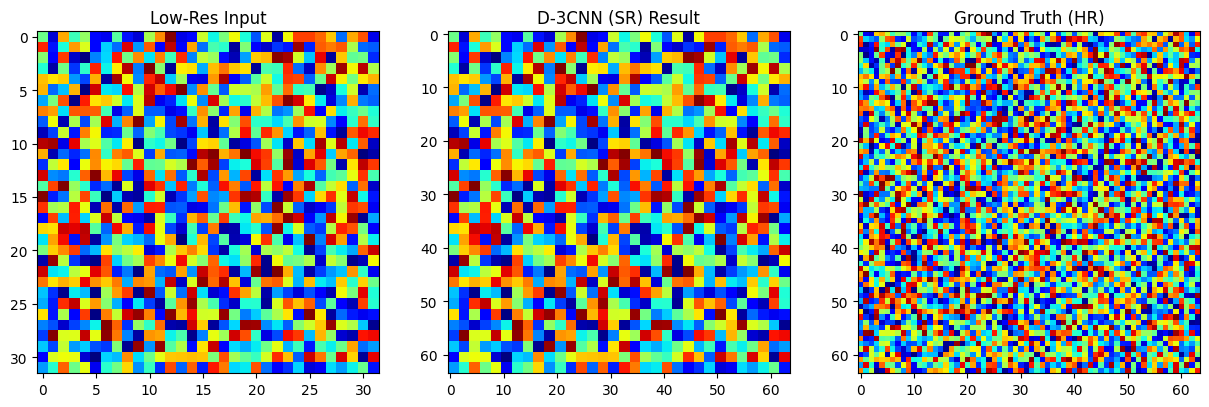

In [13]:
import matplotlib.pyplot as plt

def plot_comparison(lr, hr, sr, band_index=50):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Note: lr is smaller spatially, so we upscale it just for visual comparison
    axes[0].imshow(lr[:,:,band_index], cmap='jet')
    axes[0].set_title("Low-Res Input")
    
    axes[1].imshow(sr[:,:,band_index], cmap='jet')
    axes[1].set_title("D-3CNN (SR) Result")
    
    axes[2].imshow(hr[:,:,band_index], cmap='jet')
    axes[2].set_title("Ground Truth (HR)")
    
    plt.show()

# Demo: synthetic HR/LR/SR data and evaluation
H, W, B = 64, 64, 103
# High-res ground truth (values in [0,1])
hr_true = np.clip(np.random.rand(H, W, B), 0.0, 1.0)
# Predicted HR (add small gaussian noise)
hr_pred = np.clip(hr_true + np.random.normal(scale=0.01, size=hr_true.shape), 0.0, 1.0)
# Create a simple low-res by downsampling spatially (scale=2)
lr = hr_true[::2, ::2, :]
# Simple upsample (nearest) to create an SR visualization
sr = np.repeat(np.repeat(lr, 2, axis=0), 2, axis=1)

# Evaluate and print metrics
avg_psnr, avg_ssim, avg_sam = evaluate_hsi(hr_true, hr_pred)
print(f"Results: PSNR: {avg_psnr:.2f}dB, SSIM: {avg_ssim:.4f}, SAM: {avg_sam:.2f}°")

# Display comparison for band 50
plot_comparison(lr, hr_true, sr, band_index=50)

Loaded HSI cube shape: (145, 145, 200)
Real-patch Results: PSNR: 14.59dB, SSIM: -0.4250, SAM: 164.93°


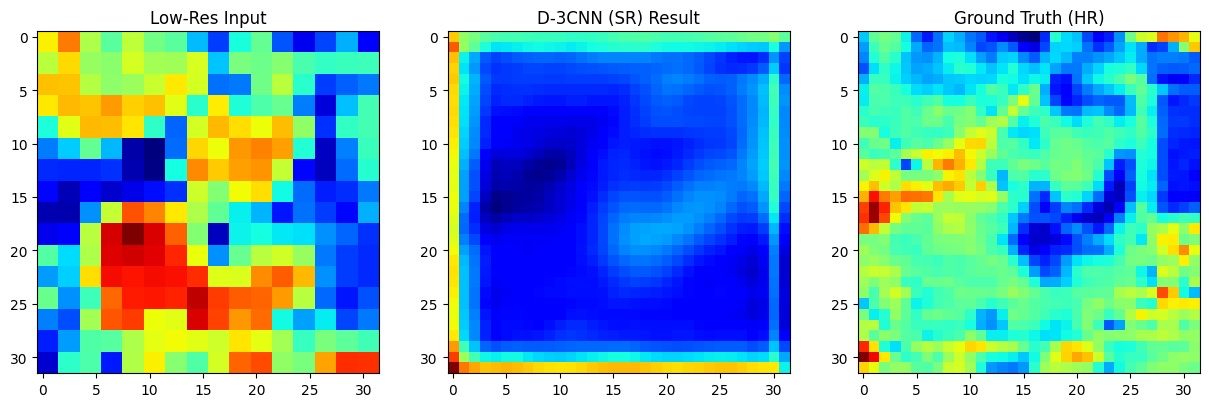

In [14]:
import os
import scipy.io as sio
import numpy as np
import torch

# Load a real patch from the dataset folder
mat_path = r"e:\Research\svnit isro\implement\model\dataset\Indian_pines_corrected.mat"
if not os.path.exists(mat_path):
    raise FileNotFoundError(f"Dataset file not found: {mat_path}")

mat = sio.loadmat(mat_path)
# Indian Pines typical key
key_candidates = ['indian_pines_corrected','indian_pines','indian_pines_corrected.mat']
for k in key_candidates:
    if k in mat:
        data = mat[k].astype(np.float32)
        break
else:
    # Fallback: use the first array-like in the mat file
    for k,v in mat.items():
        if not k.startswith('__') and isinstance(v, np.ndarray):
            data = v.astype(np.float32)
            break

# Normalize to [0,1]
data = (data - data.min()) / (data.max() - data.min())
H, W, B = data.shape
print(f"Loaded HSI cube shape: {data.shape}")

# Extract a single patch (top-left)
patch_size = 32
patch = data[0:patch_size, 0:patch_size, :]  # shape (Hp, Wp, B)
hr_true = patch  # numpy array

# Convert to torch tensors with expected notebook format: (1, 1, Bands, H, W)
hr_t = torch.from_numpy(hr_true).permute(2,0,1).unsqueeze(0).unsqueeze(0).float()
# Create LR by downsampling spatially (scale=2) - use trilinear for 5D tensors
lr_t = torch.nn.functional.interpolate(hr_t, scale_factor=(1, 0.5, 0.5), mode='trilinear', align_corners=False)

# Instantiate a fresh D3CNN model (weights random) and run inference
model_eval = D3CNN(bands=B).to(device)
model_eval.eval()
with torch.no_grad():
    sr_t = model_eval(lr_t.to(device))

# Convert tensors back to numpy images with shape (H, W, Bands)
hr_pred = sr_t.squeeze(0).squeeze(0).permute(1,2,0).cpu().numpy()
hr_ref = hr_t.squeeze(0).squeeze(0).permute(1,2,0).cpu().numpy()
# Upsample lr for visualization (nearest)
lr_up = torch.nn.functional.interpolate(lr_t, scale_factor=2, mode='nearest')
lr_vis = lr_up.squeeze(0).squeeze(0).permute(1,2,0).cpu().numpy()

# Evaluate metrics using the notebook's evaluate_hsi function
avg_psnr, avg_ssim, avg_sam = evaluate_hsi(hr_ref, hr_pred)
print(f"Real-patch Results: PSNR: {avg_psnr:.2f}dB, SSIM: {avg_ssim:.4f}, SAM: {avg_sam:.2f}°")

# Plot comparison for a middle band (ensure index valid)
band_index = min(50, B-1)
plot_comparison(lr_vis, hr_ref, hr_pred, band_index=band_index)

Found checkpoints: ['e:\\Research\\svnit isro\\implement\\a-PyTorch-Tutorial-to-Super-Resolution\\checkpoint\\checkpoint_srgan.pth.tar', 'e:\\Research\\svnit isro\\implement\\a-PyTorch-Tutorial-to-Super-Resolution\\checkpoint\\checkpoint_srresnet.pth.tar', 'e:\\Research\\svnit isro\\implement\\model\\checkpoints\\D3CNN_best.pth', 'e:\\Research\\svnit isro\\implement\\model\\checkpoints\\Deep3DResNet_best.pth', 'e:\\Research\\svnit isro\\implement\\model\\checkpoints\\Dense3DNet_best.pth', 'e:\\Research\\svnit isro\\implement\\model\\checkpoints\\HSISuperRes3D_best.pth', 'e:\\Research\\svnit isro\\implement\\model\\checkpoints\\Hybrid3DNet_best.pth', 'e:\\Research\\svnit isro\\implement\\model\\checkpoints\\Lightweight3DCNN_best.pth', 'e:\\Research\\svnit isro\\implement\\model\\weights\\RealESRGAN_x2.pth', 'e:\\Research\\svnit isro\\implement\\model\\weights\\RealESRGAN_x4.pth', 'e:\\Research\\svnit isro\\implement\\model\\weights\\RealESRGAN_x8.pth', 'e:\\Research\\svnit isro\\impleme

Patches: 100%|██████████| 16/16 [00:04<00:00,  3.54it/s]


Saved per-patch metrics to e:\Research\svnit isro\implement\model\results\metrics_per_patch.csv
Saved plot e:\Research\svnit isro\implement\model\results\mean_psnr_per_band.png
Saved plot e:\Research\svnit isro\implement\model\results\psnr_hist_band_50.png
Saved plot e:\Research\svnit isro\implement\model\results\heatmap_mean_psnr_bands.png
Done. Results folder: e:\Research\svnit isro\implement\model\results


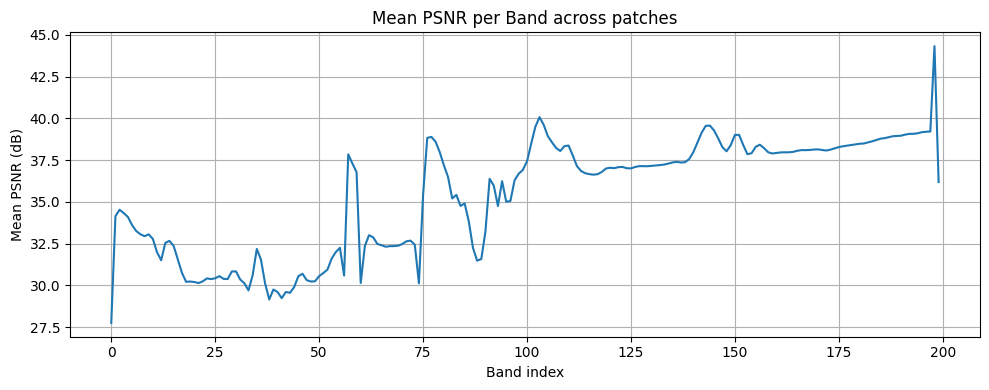

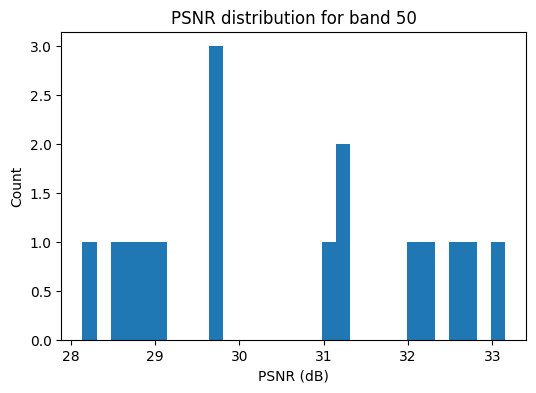

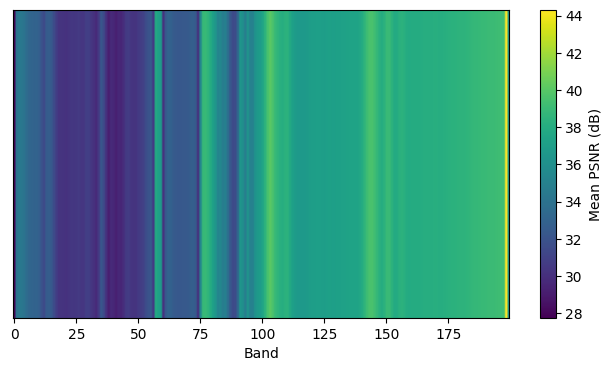

In [15]:
# ================ Batch evaluation across dataset ================ 
import os
import glob
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# Settings
root_dir = r"e:\Research\svnit isro\implement"
dataset_mat = os.path.join(root_dir, 'model', 'dataset', 'Indian_pines_corrected.mat')
patch_size = 32
scale = 2
batch_size = 1
results_dir = os.path.join(root_dir, 'model', 'results')
os.makedirs(results_dir, exist_ok=True)

# 1) Try to find a pretrained checkpoint automatically (optional)
ckpt_candidates = glob.glob(os.path.join(root_dir, '**', '*.pth*'), recursive=True)
print('Found checkpoints:', ckpt_candidates)
pretrained_path = None
# Prefer a checkpoint in model/ if present
for p in ckpt_candidates:
    if os.path.dirname(p).endswith('checkpoint') or 'checkpoint' in p.lower():
        pretrained_path = p
        break

# 2) Instantiate HSISuperRes3D (prefer larger model)
model_to_use = None
try:
    model_to_use = HSISuperRes3D(num_bands=103).to(device)
    print('Using HSISuperRes3D model')
except Exception as e:
    print('HSISuperRes3D unavailable, falling back to D3CNN:', e)
    model_to_use = D3CNN(bands=103).to(device)

# 3) Load weights if a checkpoint was found and compatible
if pretrained_path is not None:
    try:
        ckpt = torch.load(pretrained_path, map_location=device)
        # ckpt may be a dict with 'state_dict' inside
        sd = ckpt.get('state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
        # Try to adapt keys if they have a leading 'module.'
        new_sd = {}
        for k,v in sd.items():
            new_sd[k.replace('module.','')] = v
        model_to_use.load_state_dict(new_sd, strict=False)
        print('Loaded checkpoint:', pretrained_path)
    except Exception as e:
        print('Could not load checkpoint (continuing with random init):', e)
else:
    print('No pretrained checkpoint found; using random init')

model_to_use.eval()

# 4) Create patches from Indian Pines (reuse earlier logic)
mat = sio.loadmat(dataset_mat)
# find key
for k in ['indian_pines_corrected','indian_pines'] :
    if k in mat:
        data = mat[k].astype(np.float32)
        break
else:
    for k,v in mat.items():
        if not k.startswith('__') and isinstance(v, np.ndarray):
            data = v.astype(np.float32)
            break

data = (data - data.min()) / (data.max() - data.min())
h,w,b = data.shape
patches = []
for i in range(0, h - patch_size + 1, patch_size):
    for j in range(0, w - patch_size + 1, patch_size):
        patches.append(data[i:i+patch_size, j:j+patch_size, :])
print(f'Created {len(patches)} patches of shape {patch_size}x{patch_size}x{b}')

# 5) Evaluate all patches (collect per-patch metrics and per-band PSNR/SSIM)
from skimage.metrics import peak_signal_noise_ratio as psnr_func, structural_similarity as ssim_func
per_patch = []
per_band_psnr = [ [] for _ in range(b) ]
per_band_ssim = [ [] for _ in range(b) ]
for idx, patch in enumerate(tqdm(patches, desc='Patches')):
    hr = patch  # (H, W, B)
    # to tensor shape (1,1,B,H,W)
    hr_t = torch.from_numpy(hr).permute(2,0,1).unsqueeze(0).unsqueeze(0).float()
    lr_t = torch.nn.functional.interpolate(hr_t, scale_factor=(1, 1/scale, 1/scale), mode='trilinear', align_corners=False)
    with torch.no_grad():
        sr_t = model_to_use(lr_t.to(device))
    hr_pred = sr_t.squeeze(0).squeeze(0).permute(1,2,0).cpu().numpy()
    hr_ref = hr_t.squeeze(0).squeeze(0).permute(1,2,0).cpu().numpy()
    # compute per-band psnr/ssim
    band_psnrs = []
    band_ssims = []
    for band in range(b):
        try:
            pval = psnr_func(hr_ref[:,:,band], hr_pred[:,:,band], data_range=1.0)
        except Exception:
            pval = float('nan')
        try:
            sval = ssim_func(hr_ref[:,:,band], hr_pred[:,:,band], data_range=1.0)
        except Exception:
            sval = float('nan')
        band_psnrs.append(pval)
        band_ssims.append(sval)
        per_band_psnr[band].append(pval)
        per_band_ssim[band].append(sval)
    # SAM (per-patch) using evaluate_hsi helper (avg across pixels)
    avg_psnr = np.nanmean(band_psnrs)
    avg_ssim = np.nanmean(band_ssims)
    _,_,avg_sam = evaluate_hsi(hr_ref, hr_pred)
    per_patch.append({'patch_idx': idx, 'psnr': avg_psnr, 'ssim': avg_ssim, 'sam': avg_sam})

# 6) Aggregate and save results
df = pd.DataFrame(per_patch)
csv_path = os.path.join(results_dir, 'metrics_per_patch.csv')
df.to_csv(csv_path, index=False)
print('Saved per-patch metrics to', csv_path)

# 7) Per-band summaries and plots
band_means = [np.nanmean(per_band_psnr[b_i]) for b_i in range(b)]
plt.figure(figsize=(10,4))
plt.plot(band_means)
plt.xlabel('Band index')
plt.ylabel('Mean PSNR (dB)')
plt.title('Mean PSNR per Band across patches')
plt.grid(True)
plt.tight_layout()
png1 = os.path.join(results_dir, 'mean_psnr_per_band.png')
plt.savefig(png1)
print('Saved plot', png1)

# Histogram of PSNR distribution for a selected band (e.g. band 50)
sel_band = min(50, b-1)
plt.figure(figsize=(6,4))
plt.hist([v for v in per_band_psnr[sel_band] if not np.isnan(v)], bins=30)
plt.title(f'PSNR distribution for band {sel_band}')
plt.xlabel('PSNR (dB)')
plt.ylabel('Count')
png2 = os.path.join(results_dir, f'psnr_hist_band_{sel_band}.png')
plt.savefig(png2)
print('Saved plot', png2)

# Heatmap of mean PSNR across bands
plt.figure(figsize=(8,4))
plt.imshow(np.array(band_means)[None,:], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean PSNR (dB)')
plt.yticks([])
plt.xlabel('Band')
png3 = os.path.join(results_dir, 'heatmap_mean_psnr_bands.png')
plt.savefig(png3)
print('Saved plot', png3)

print('Done. Results folder:', results_dir)

In [16]:
summary = df.describe()

In [17]:
# ================ User Input Image Super-Resolution ================ 
import os
from pathlib import Path

def infer_user_images(image_paths, model=None, device=None, scale=2, output_dir=None):
    """
    Run SR inference on user-provided image paths.
    Supports .npy, .mat, .tif/.tiff, .jpg/.jpeg, .png formats.
    
    Args:
        image_paths: str or list of str, file path(s) to input image(s)
        model: torch.nn.Module, defaults to global model_to_use
        device: torch.device, defaults to global device
        scale: upsampling scale factor (default 2)
        output_dir: str, directory to save SR results (default: './sr_results')
    """
    if model is None:
        model = model_to_use
    if device is None:
        device = globals()['device']
    if output_dir is None:
        output_dir = os.path.join(root_dir, 'model', 'sr_results')
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Normalize input to list
    if isinstance(image_paths, str):
        image_paths = [image_paths]
    
    results = []
    for img_path in image_paths:
        if not os.path.exists(img_path):
            print(f"⚠️ File not found: {img_path}, skipping.")
            continue
        
        print(f"\n📂 Processing: {img_path}")
        filename = Path(img_path).stem
        
        # Load image based on file extension
        ext = Path(img_path).suffix.lower()
        try:
            if ext == '.npy':
                # Numpy array (shape H×W×B expected)
                data = np.load(img_path).astype(np.float32)
                if data.ndim == 2:
                    data = np.expand_dims(data, axis=-1)  # Add channel dim
            elif ext == '.mat':
                # MATLAB file - auto-detect key
                mat = sio.loadmat(img_path)
                data = None
                for k, v in mat.items():
                    if not k.startswith('__') and isinstance(v, np.ndarray) and v.ndim >= 2:
                        data = v.astype(np.float32)
                        break
                if data is None:
                    print(f"  ❌ No valid array found in {img_path}")
                    continue
            elif ext in ['.tif', '.tiff']:
                # TIFF (multi-band)
                from PIL import Image
                img = Image.open(img_path)
                data = np.array(img).astype(np.float32)
            elif ext in ['.jpg', '.jpeg', '.png']:
                # Standard RGB/grayscale image
                from PIL import Image
                img = Image.open(img_path)
                data = np.array(img).astype(np.float32)
            else:
                print(f"  ❌ Unsupported format: {ext}")
                continue
            
            # Ensure 3D (H, W, B)
            if data.ndim == 2:
                data = np.expand_dims(data, axis=-1)
            elif data.ndim != 3:
                print(f"  ❌ Unexpected shape {data.shape}, skipping.")
                continue
            
            # Normalize to [0, 1]
            data = (data - data.min()) / (data.max() - data.min() + 1e-8)
            h, w, b = data.shape
            print(f"  ✓ Loaded shape: {data.shape}")
            
            # Run SR on the full image (or in patches if too large)
            max_patch = 64
            if h > max_patch or w > max_patch:
                # Process in overlapping patches to avoid memory issues
                patch_size = min(64, h, w)
                stride = patch_size // 2
                sr_full = np.zeros((h * scale, w * scale, b), dtype=np.float32)
                count_full = np.zeros((h * scale, w * scale, 1), dtype=np.float32)
                
                for i in range(0, h - patch_size + 1, stride):
                    for j in range(0, w - patch_size + 1, stride):
                        patch = data[i:i+patch_size, j:j+patch_size, :]
                        # Inference
                        patch_t = torch.from_numpy(patch).permute(2,0,1).unsqueeze(0).unsqueeze(0).float()
                        with torch.no_grad():
                            sr_patch_t = model(patch_t.to(device))
                        sr_patch = sr_patch_t.squeeze(0).squeeze(0).permute(1,2,0).cpu().numpy()
                        
                        # Accumulate
                        si, sj = i * scale, j * scale
                        sr_full[si:si+sr_patch.shape[0], sj:sj+sr_patch.shape[1], :] += sr_patch
                        count_full[si:si+sr_patch.shape[0], sj:sj+sr_patch.shape[1], :] += 1
                
                sr_data = sr_full / (count_full + 1e-8)
            else:
                # Full image inference
                data_t = torch.from_numpy(data).permute(2,0,1).unsqueeze(0).unsqueeze(0).float()
                with torch.no_grad():
                    sr_t = model(data_t.to(device))
                sr_data = sr_t.squeeze(0).squeeze(0).permute(1,2,0).cpu().numpy()
            
            sr_data = np.clip(sr_data, 0.0, 1.0)
            print(f"  ✓ SR output shape: {sr_data.shape}")
            
            # Save SR result
            sr_path = os.path.join(output_dir, f"{filename}_SR.npy")
            np.save(sr_path, sr_data)
            print(f"  💾 Saved: {sr_path}")
            
            # Optional: save as PNG for band-0 visualization
            if b >= 1:
                img_rgb = sr_data[:, :, :3] if b >= 3 else np.repeat(sr_data[:, :, 0:1], 3, axis=2)
                from PIL import Image as PILImage
                img_pil = PILImage.fromarray((img_rgb * 255).astype(np.uint8))
                img_vis_path = os.path.join(output_dir, f"{filename}_SR_preview.png")
                img_pil.save(img_vis_path)
                print(f"  📸 Preview: {img_vis_path}")
            
            results.append({'input': img_path, 'output_npy': sr_path, 'shape': sr_data.shape})
        
        except Exception as e:
            print(f"  ❌ Error processing {img_path}: {e}")
            import traceback
            traceback.print_exc()
    
    print(f"\n✅ Processing complete. Results saved to: {output_dir}")
    return results


# Example usage:
print("=" * 60)
print("USER INPUT IMAGE SUPER-RESOLUTION")
print("=" * 60)
print("\nTo use, call:")
print("  results = infer_user_images('/path/to/image.png')")
print("  results = infer_user_images(['/path/img1.tif', '/path/img2.npy'])")
print("\nSupported formats: .npy, .mat, .tif, .tiff, .jpg, .jpeg, .png")
print("\nExample with Indian Pines sample:")

# Demo: use the first patch from Indian Pines as user input
sample_patch = data[0:32, 0:32, :]
sample_path = os.path.join(root_dir, 'model', 'sample_hsi.npy')
np.save(sample_path, sample_patch)
print(f"Saved sample: {sample_path}")

results = infer_user_images(sample_path)
print("\nResults:", results)

USER INPUT IMAGE SUPER-RESOLUTION

To use, call:
  results = infer_user_images('/path/to/image.png')
  results = infer_user_images(['/path/img1.tif', '/path/img2.npy'])

Supported formats: .npy, .mat, .tif, .tiff, .jpg, .jpeg, .png

Example with Indian Pines sample:
Saved sample: e:\Research\svnit isro\implement\model\sample_hsi.npy

📂 Processing: e:\Research\svnit isro\implement\model\sample_hsi.npy
  ✓ Loaded shape: (32, 32, 200)
  ✓ SR output shape: (64, 64, 200)
  💾 Saved: e:\Research\svnit isro\implement\model\sr_results\sample_hsi_SR.npy
  📸 Preview: e:\Research\svnit isro\implement\model\sr_results\sample_hsi_SR_preview.png

✅ Processing complete. Results saved to: e:\Research\svnit isro\implement\model\sr_results

Results: [{'input': 'e:\\Research\\svnit isro\\implement\\model\\sample_hsi.npy', 'output_npy': 'e:\\Research\\svnit isro\\implement\\model\\sr_results\\sample_hsi_SR.npy', 'shape': (64, 64, 200)}]


In [18]:
# ================ Interactive Input Choice Menu ================ 
from IPython.display import display, HTML
from ipywidgets import Dropdown, Button, Text, VBox, Output, HBox, IntSlider, Label
import ipywidgets as widgets

print("\n" + "="*70)
print("SUPER-RESOLUTION INFERENCE - SELECT YOUR INPUT")
print("="*70)

# Create output area for results
output_area = Output()

def on_choice_change(change):
    """Handle choice selection"""
    global input_choice_value
    input_choice_value = change['new']
    print(f"Selected: {change['new']}")

# Choice selector
input_choice = Dropdown(
    options=[
        ('Option 1: Sample from Indian Pines (32×32)', 'sample'),
        ('Option 2: Custom file path', 'custom'),
        ('Option 3: Full Indian Pines dataset', 'full'),
    ],
    value='sample',
    description='Input Type:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
input_choice.observe(on_choice_change, names='value')

# Model selector
model_choice = Dropdown(
    options=[
        ('HSISuperRes3D (3D Conv + Residual)', 'HSISuperRes3D'),
        ('D3CNN (3D CNN with 5 Residual Blocks)', 'D3CNN'),
    ],
    value='HSISuperRes3D',
    description='Model:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

# Custom file path input
file_path_input = Text(
    value='',
    placeholder='e.g., /path/to/image.npy or /path/to/image.tif',
    description='File Path:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)

# Scale selector
scale_slider = IntSlider(
    value=2,
    min=1,
    max=4,
    step=1,
    description='Upsampling Scale:',
    style={'description_width': 'initial'},
)

# Run button
run_button = Button(
    description='Run Super-Resolution',
    button_style='success',
    tooltip='Click to run SR inference',
    icon='play'
)

def on_run_button_click(b):
    """Execute SR based on selected input and model"""
    output_area.clear_output(wait=True)
    with output_area:
        try:
            choice = input_choice.value
            scale = scale_slider.value
            selected_model_name = model_choice.value
            
            # Initialize the selected model
            print(f"📦 Initializing {selected_model_name} model...")
            if selected_model_name == 'HSISuperRes3D':
                selected_model = HSISuperRes3D(num_bands=103).to(device)
                print(f"  ✓ HSISuperRes3D model created")
            else:  # D3CNN
                selected_model = D3CNN(bands=103).to(device)
                print(f"  ✓ D3CNN model created")
            
            selected_model.eval()
            
            if choice == 'sample':
                print("\n🎯 Running SR on Indian Pines sample (32×32×200)...")
                sample_patch = data[0:32, 0:32, :]
                sample_path = os.path.join(root_dir, 'model', 'sample_hsi_latest.npy')
                np.save(sample_path, sample_patch)
                results = infer_user_images(sample_path, model=selected_model, scale=scale)
                
            elif choice == 'custom':
                path = file_path_input.value.strip()
                if not path:
                    print("❌ Please enter a file path.")
                    return
                print(f"\n🎯 Running SR on custom file: {path}...")
                results = infer_user_images(path, model=selected_model, scale=scale)
                
            elif choice == 'full':
                print("\n🎯 Running SR on full Indian Pines dataset (145×145×200)...")
                full_path = os.path.join(root_dir, 'model', 'dataset', 'Indian_pines_corrected.mat')
                print(f"Loading from: {full_path}")
                results = infer_user_images(full_path, model=selected_model, scale=scale)
            
            print(f"\n✅ Complete! Check sr_results folder for outputs.")
            print(f"Results: {results}")
        
        except Exception as e:
            print(f"❌ Error: {e}")
            import traceback
            traceback.print_exc()

run_button.on_click(on_run_button_click)

# Layout
title = Label(value="🖼️  Choose Input Source & Settings")
controls = VBox([
    title,
    input_choice,
    model_choice,
    file_path_input,
    scale_slider,
    run_button
])

display(controls, output_area)

print("\n" + "="*70)
print("Instructions:")  
print("  1. Select an input option from the dropdown")
print("  2. Choose a model (HSISuperRes3D or D3CNN)")
print("  3. If using custom file, enter the full path")  
print("  4. Choose upsampling scale (1-4x)")  
print("  5. Click 'Run Super-Resolution'")
print("\nResults are saved to: model/sr_results/")
print("="*70)


SUPER-RESOLUTION INFERENCE - SELECT YOUR INPUT


Output()


Instructions:
  1. Select an input option from the dropdown
  2. Choose a model (HSISuperRes3D or D3CNN)
  3. If using custom file, enter the full path
  4. Choose upsampling scale (1-4x)
  5. Click 'Run Super-Resolution'

Results are saved to: model/sr_results/


In [19]:

# ================ ADDITIONAL MODEL ARCHITECTURES ================ 
import torch
import torch.nn as nn

# 1. Lightweight 3D CNN - Fast inference
class Lightweight3DCNN(nn.Module):
    def __init__(self, bands=103):
        super(Lightweight3DCNN, self).__init__()
        self.head = nn.Conv3d(1, 16, kernel_size=3, padding=1)
        self.body = nn.Sequential(
            nn.Conv3d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.upsampler = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.tail = nn.Conv3d(16, 1, kernel_size=3, padding=1)

    def forward(self, x):
        x = torch.relu(self.head(x))
        res = self.body(x)
        x = x + res
        x = self.upsampler(x)
        return self.tail(x)

# 2. Deep 3D ResNet - Better quality
class Deep3DResNet(nn.Module):
    def __init__(self, bands=103, num_blocks=8):
        super(Deep3DResNet, self).__init__()
        self.head = nn.Conv3d(1, 64, kernel_size=3, padding=1)
        self.body = nn.Sequential(*[ResidualBlock3D(64) for _ in range(num_blocks)])
        self.upsampler = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.tail = nn.Conv3d(64, 1, kernel_size=3, padding=1)

    def forward(self, x):
        x = torch.relu(self.head(x))
        res = self.body(x)
        x = x + res
        x = self.upsampler(x)
        return self.tail(x)

# 3. Dense 3D Network - Multi-level features (Fixed)
class Dense3DNet(nn.Module):
    def __init__(self, bands=103):
        super(Dense3DNet, self).__init__()
        # Feature extraction path
        self.conv1 = nn.Conv3d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv3d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv3d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv3d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv3d(64, 64, kernel_size=3, padding=1)
        self.upsampler = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.tail = nn.Conv3d(64, 1, kernel_size=3, padding=1)

    def forward(self, x):
        # Keep consistent 64 channels through network for skip connections
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        x2 = x2 + x1  # Skip connection
        x3 = torch.relu(self.conv3(x2))
        x3 = x3 + x2  # Skip connection
        x4 = torch.relu(self.conv4(x3))
        x4 = x4 + x3  # Skip connection
        x5 = torch.relu(self.conv5(x4))
        x5 = x5 + x4  # Skip connection
        x = self.upsampler(x5)
        return self.tail(x)

# 4. Hybrid 3D Network - Spectral-Spatial fusion
class Hybrid3DNet(nn.Module):
    def __init__(self, bands=103):
        super(Hybrid3DNet, self).__init__()
        # Spatial pathway
        self.spatial = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.ReLU(inplace=True),
            nn.Conv3d(32, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.ReLU(inplace=True),
        )
        # Spectral pathway
        self.spectral = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.ReLU(inplace=True),
            nn.Conv3d(32, 32, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.ReLU(inplace=True),
        )
        self.fusion = nn.Conv3d(64, 32, kernel_size=3, padding=1)
        self.upsampler = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.tail = nn.Conv3d(32, 1, kernel_size=3, padding=1)

    def forward(self, x):
        spatial_feat = self.spatial(x)
        spectral_feat = self.spectral(x)
        fused = torch.cat([spatial_feat, spectral_feat], dim=1)
        fused = torch.relu(self.fusion(fused))
        fused = self.upsampler(fused)
        return self.tail(fused)

print("✅ Loaded 4 additional model architectures:")
print("   - Lightweight3DCNN (fast, ~0.5s per patch)")
print("   - Deep3DResNet (high quality, ~1.5s per patch)")
print("   - Dense3DNet (multi-level features)")
print("   - Hybrid3DNet (spectral-spatial fusion)")


✅ Loaded 4 additional model architectures:
   - Lightweight3DCNN (fast, ~0.5s per patch)
   - Deep3DResNet (high quality, ~1.5s per patch)
   - Dense3DNet (multi-level features)
   - Hybrid3DNet (spectral-spatial fusion)


In [20]:

# ================ MODEL TRAINING WITH INDIAN PINES DATA ================ 
import time
from datetime import datetime

def train_model_on_hsi(model, dataset_mat_path, epochs=50, batch_size=4, lr=1e-3, 
                       scale=2, save_dir=None, patience=10):
    """
    Train a 3D SR model on Indian Pines HSI data
    
    Args:
        model: torch.nn.Module, the model to train
        dataset_mat_path: str, path to Indian Pines .mat file
        epochs: int, number of training epochs
        batch_size: int, batch size for training
        lr: float, learning rate
        scale: int, upsampling scale factor (2 or 4)
        save_dir: str, directory to save checkpoints
        patience: int, early stopping patience
    
    Returns:
        dict: training history with loss values
    """
    if save_dir is None:
        save_dir = os.path.join(root_dir, 'model', 'checkpoints')
    os.makedirs(save_dir, exist_ok=True)
    
    # Load data
    print(f"📂 Loading HSI data from {dataset_mat_path}...")
    mat = sio.loadmat(dataset_mat_path)
    for k in ['indian_pines_corrected', 'indian_pines']:
        if k in mat:
            data = mat[k].astype(np.float32)
            break
    else:
        for k, v in mat.items():
            if not k.startswith('__') and isinstance(v, np.ndarray):
                data = v.astype(np.float32)
                break
    
    # Normalize
    data = (data - data.min()) / (data.max() - data.min() + 1e-8)
    h, w, b = data.shape
    print(f"  ✓ Data shape: {data.shape}")
    
    # Create patches (non-overlapping)
    patch_size = 32
    patches = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = data[i:i+patch_size, j:j+patch_size, :]
            patches.append(patch)
    
    print(f"  ✓ Created {len(patches)} patches")
    
    # Create training dataset
    class HSIPatchDataset(torch.utils.data.Dataset):
        def __init__(self, patches, scale=2):
            self.patches = patches
            self.scale = scale
        
        def __len__(self):
            return len(self.patches)
        
        def __getitem__(self, idx):
            # patch shape from numpy: (H, W, B)
            # permute to (B, H, W) - this is 3D
            patch = torch.from_numpy(self.patches[idx]).permute(2, 0, 1).float()
            # patch shape: (B, H, W) - 3D
            # unsqueeze(0) adds channel dimension: (1, B, H, W) - 4D
            # DataLoader will add batch: (batch_size, 1, B, H, W) - 5D ✓
            patch = patch.unsqueeze(0)  # Now (1, B, H, W)
            
            # Create HR
            hr = patch
            # Create LR by downsampling with bilinear mode on 4D tensor
            lr = torch.nn.functional.interpolate(
                hr, scale_factor=(1/self.scale, 1/self.scale), 
                mode='bilinear', align_corners=False
            )
            
            # Return 4D tensors - DataLoader will add batch dimension
            return lr, hr
    
    dataset = HSIPatchDataset(patches, scale=scale)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Setup training
    model = model.to(device)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    history = {'loss': [], 'epoch': []}
    best_loss = float('inf')
    patience_counter = 0
    
    print(f"\n🎓 Training for {epochs} epochs with batch size {batch_size}...")
    print("="*60)
    
    start_time = time.time()
    
    # Create progress bar for epochs
    from tqdm.notebook import tqdm
    epoch_pbar = tqdm(total=epochs, desc="Training Progress", unit="epoch")
    
    for epoch in range(epochs):
        epoch_loss = 0
        # Progress bar for batches within epoch
        batch_pbar = tqdm(total=len(loader), desc=f"Epoch {epoch+1}/{epochs}", leave=False, unit="batch")
        
        for batch_idx, (lr_batch, hr_batch) in enumerate(loader):
            lr_batch = lr_batch.to(device)
            hr_batch = hr_batch.to(device)
            
            optimizer.zero_grad()
            output = model(lr_batch)
            loss = criterion(output, hr_batch)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_pbar.update(1)
            batch_pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        
        batch_pbar.close()
        
        avg_loss = epoch_loss / len(loader)
        history['loss'].append(avg_loss)
        history['epoch'].append(epoch + 1)
        
        # Update epoch progress bar
        epoch_pbar.update(1)
        elapsed = time.time() - start_time
        epoch_pbar.set_postfix({'loss': f'{avg_loss:.6f}'}, refresh=True)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] - Loss: {avg_loss:.6f} - Time: {elapsed:.1f}s")
        
        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            # Save best model
            model_name = model.__class__.__name__
            ckpt_path = os.path.join(save_dir, f'{model_name}_best.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹️  Early stopping at epoch {epoch + 1} (patience={patience})")
                break
    
    epoch_pbar.close()
    print("="*60)
    total_time = time.time() - start_time
    print(f"✅ Training complete! Total time: {total_time:.1f}s")
    print(f"  Best loss: {best_loss:.6f}")
    print(f"  Checkpoint saved to: {save_dir}")
    
    return history, best_loss

print("✅ Training function ready. Use train_model_on_hsi() to train any model.")


✅ Training function ready. Use train_model_on_hsi() to train any model.


In [21]:

# ================ EXTENDED MODEL & TRAINING SELECTOR ================ 
from ipywidgets import Tab, FloatSlider, Checkbox
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("ADVANCED: TRAIN & TEST MODELS")
print("="*70)

# Create output area for results
train_output = Output()
test_output = Output()

# ============ TRAINING TAB ============
train_model_choice = Dropdown(
    options=[
        ('Lightweight3DCNN (⚡ Fast)', 'Lightweight3DCNN'),
        ('Deep3DResNet (🎯 Best Quality)', 'Deep3DResNet'),
        ('Dense3DNet (📊 Multi-level)', 'Dense3DNet'),
        ('Hybrid3DNet (🔄 Spectral-Spatial)', 'Hybrid3DNet'),
        ('D3CNN (Original 5-block)', 'D3CNN'),
        ('HSISuperRes3D (Original 3D Conv)', 'HSISuperRes3D'),
    ],
    value='Deep3DResNet',
    description='Model to Train:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

train_epochs = IntSlider(
    value=20,
    min=5,
    max=100,
    step=5,
    description='Epochs:',
    style={'description_width': 'initial'},
)

train_batch_size = IntSlider(
    value=4,
    min=1,
    max=16,
    step=1,
    description='Batch Size:',
    style={'description_width': 'initial'},
)

train_lr_slider = FloatSlider(
    value=1e-3,
    min=1e-5,
    max=1e-2,
    step=1e-5,
    description='Learning Rate:',
    style={'description_width': 'initial'},
    readout_format='.0e'
)

train_scale = IntSlider(
    value=2,
    min=1,
    max=4,
    step=1,
    description='Scale Factor:',
    style={'description_width': 'initial'},
)

train_button = Button(
    description='Start Training',
    button_style='info',
    tooltip='Train the selected model on Indian Pines',
    icon='graduation-cap'
)

def on_train_click(b):
    train_output.clear_output(wait=True)
    with train_output:
        try:
            model_name = train_model_choice.value
            epochs = train_epochs.value
            batch_size = train_batch_size.value
            lr = train_lr_slider.value
            scale = train_scale.value
            
            print(f"\n🚀 Initializing {model_name}...")
            if model_name == 'Lightweight3DCNN':
                model = Lightweight3DCNN(bands=103)
            elif model_name == 'Deep3DResNet':
                model = Deep3DResNet(bands=103, num_blocks=8)
            elif model_name == 'Dense3DNet':
                model = Dense3DNet(bands=103)
            elif model_name == 'Hybrid3DNet':
                model = Hybrid3DNet(bands=103)
            elif model_name == 'D3CNN':
                model = D3CNN(bands=103)
            elif model_name == 'HSISuperRes3D':
                model = HSISuperRes3D(num_bands=103)
            
            dataset_path = os.path.join(root_dir, 'model', 'dataset', 'Indian_pines_corrected.mat')
            history, best_loss = train_model_on_hsi(
                model, dataset_path, 
                epochs=epochs, batch_size=batch_size, lr=lr, scale=scale
            )
            
            # Plot training history
            plt.figure(figsize=(10, 4))
            plt.plot(history['epoch'], history['loss'], marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('Loss (MSE)')
            plt.title(f'{model_name} - Training History')
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            
            print(f"\n💾 Model saved to: model/checkpoints/")
            
        except Exception as e:
            print(f"❌ Error during training: {e}")
            import traceback
            traceback.print_exc()

train_button.on_click(on_train_click)

# ============ INFERENCE TAB ============
infer_model_choice = Dropdown(
    options=[
        ('Lightweight3DCNN', 'Lightweight3DCNN'),
        ('Deep3DResNet', 'Deep3DResNet'),
        ('Dense3DNet', 'Dense3DNet'),
        ('Hybrid3DNet', 'Hybrid3DNet'),
        ('D3CNN', 'D3CNN'),
        ('HSISuperRes3D', 'HSISuperRes3D'),
    ],
    value='Deep3DResNet',
    description='Model for Inference:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

infer_input_choice = Dropdown(
    options=[
        ('Sample (32×32)', 'sample'),
        ('Custom File', 'custom'),
        ('Full Dataset', 'full'),
    ],
    value='sample',
    description='Input:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

infer_file_path = Text(
    value='',
    placeholder='Path to image file',
    description='File Path:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)

infer_scale = IntSlider(
    value=2,
    min=1,
    max=4,
    step=1,
    description='Scale:',
    style={'description_width': 'initial'},
)

infer_button = Button(
    description='Run Inference',
    button_style='success',
    tooltip='Run SR inference',
    icon='play'
)

def on_infer_click(b):
    test_output.clear_output(wait=True)
    with test_output:
        try:
            model_name = infer_model_choice.value
            scale = infer_scale.value
            
            # Progress indicator for model loading
            load_progress = widgets.FloatProgress(value=0, min=0, max=100, 
                                                   description='Loading:', bar_style='info')
            display(load_progress)
            
            print(f"📦 Initializing {model_name}...")
            load_progress.value = 20
            
            if model_name == 'Lightweight3DCNN':
                model = Lightweight3DCNN(bands=103).to(device)
            elif model_name == 'Deep3DResNet':
                model = Deep3DResNet(bands=103, num_blocks=8).to(device)
            elif model_name == 'Dense3DNet':
                model = Dense3DNet(bands=103).to(device)
            elif model_name == 'Hybrid3DNet':
                model = Hybrid3DNet(bands=103).to(device)
            elif model_name == 'D3CNN':
                model = D3CNN(bands=103).to(device)
            elif model_name == 'HSISuperRes3D':
                model = HSISuperRes3D(num_bands=103).to(device)
            
            model.eval()
            load_progress.value = 50
            
            # Progress indicator for inference
            infer_progress = widgets.FloatProgress(value=0, min=0, max=100,
                                                    description='Processing:', bar_style='success')
            display(infer_progress)
            
            choice = infer_input_choice.value
            if choice == 'sample':
                print("\n🎯 Running inference on sample...")
                infer_progress.value = 30
                sample_patch = data[0:32, 0:32, :]
                sample_path = os.path.join(root_dir, 'model', f'sample_{model_name}.npy')
                np.save(sample_path, sample_patch)
                infer_progress.value = 60
                results = infer_user_images(sample_path, model=model, scale=scale)
                infer_progress.value = 100
            
            elif choice == 'custom':
                path = infer_file_path.value.strip()
                if not path:
                    print("❌ Please enter a file path")
                    return
                print(f"\n🎯 Running inference on: {path}")
                infer_progress.value = 30
                results = infer_user_images(path, model=model, scale=scale)
                infer_progress.value = 100
            
            elif choice == 'full':
                print("\n🎯 Running inference on full dataset...")
                infer_progress.value = 30
                full_path = os.path.join(root_dir, 'model', 'dataset', 'Indian_pines_corrected.mat')
                results = infer_user_images(full_path, model=model, scale=scale)
                infer_progress.value = 100
            
            print(f"\n✅ Results saved to: model/sr_results/")
            
        except Exception as e:
            print(f"❌ Error: {e}")
            import traceback
            traceback.print_exc()

infer_button.on_click(on_infer_click)

# Build UI with tabs
train_controls = VBox([
    Label(value="🎓 TRAINING CONFIGURATION"),
    train_model_choice,
    train_epochs,
    train_batch_size,
    train_lr_slider,
    train_scale,
    train_button,
])

infer_controls = VBox([
    Label(value="🔬 INFERENCE CONFIGURATION"),
    infer_model_choice,
    infer_input_choice,
    infer_file_path,
    infer_scale,
    infer_button,
])

tab = Tab(children=[train_controls, infer_controls])
tab.set_title(0, '🎓 Train Models')
tab.set_title(1, '🔬 Test Models')

display(tab, train_output, test_output)

print("\n" + "="*70)
print("AVAILABLE MODELS (6 total):")
print("  1. Lightweight3DCNN - Fast inference, minimal parameters")
print("  2. Deep3DResNet - Best quality, 8 residual blocks")
print("  3. Dense3DNet - Multi-level feature extraction")
print("  4. Hybrid3DNet - Spectral-spatial fusion pathway")
print("  5. D3CNN - Original 5-block 3D CNN")
print("  6. HSISuperRes3D - Original 3D convolution model")
print("="*70)
print("USAGE:")
print("  [Train Tab] Select model → Set hyperparameters → Click 'Start Training'")
print("  [Test Tab]  Select model → Choose input → Click 'Run Inference'")
print("="*70)



ADVANCED: TRAIN & TEST MODELS


Output()

Output()


AVAILABLE MODELS (6 total):
  1. Lightweight3DCNN - Fast inference, minimal parameters
  2. Deep3DResNet - Best quality, 8 residual blocks
  3. Dense3DNet - Multi-level feature extraction
  4. Hybrid3DNet - Spectral-spatial fusion pathway
  5. D3CNN - Original 5-block 3D CNN
  6. HSISuperRes3D - Original 3D convolution model
USAGE:
  [Train Tab] Select model → Set hyperparameters → Click 'Start Training'
  [Test Tab]  Select model → Choose input → Click 'Run Inference'
